# Am I gonna save all women ?

**Author** : Elsa Bidant

**Date** : 27/09/2024

Saving lives is important ! Knowing if a cancer is malignant or begnin might as a consequence improve our knowledge about cancer, and how to cure it.

**Objective**: Predict whether a cancer is malignant or benign based on various characteristics of the cell nuclei.

The dataset used can be found on UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

## 1. Library import and function construction

In [36]:
# Computing libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Graphical libraries
import seaborn as sns
import matplotlib.pyplot as plt
import dtreeviz

# Modelling libraries
from sklearn.linear_model import LogisticRegression # Logistic regression
from sklearn.tree import DecisionTreeClassifier # Decision tree
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neural_network import MLPClassifier # Neural network

In [37]:
def plot_sorted_coefficients(coef, threshold = 1e-08, regression_type='standard'):

    # Sort the coefficients by their absolute values
    sorted_coef = coef.abs().sort_values()
    
    # Get the original coefficients for coloring
    original_sorted_coef = coef.loc[sorted_coef.index]
    
    # Create a scatter plot with bars
    plt.figure(figsize = (8, 10))
    
    # Plot positive coefficients in blue, negative coefficients in yellow, and near-zero coefficients in grey
    colors = [
        'grey' if abs(c) < threshold else 'green' if c > 0 else 'red'
        for c in original_sorted_coef
    ]
    
    # Scatter plot for coefficients
    plt.scatter(sorted_coef.values, sorted_coef.index, color = colors, zorder = 5)
    
    # Plot lines from the origin to the scatter points
    for i in range(len(sorted_coef)):
        plt.plot([0, sorted_coef.values[i]], [i, i], color = 'skyblue', lw = 2)
    
    # Add vertical line at zero
    plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
    
    # Set labels and title
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')

    # Create a dynamic title based on the regression type
    if regression_type == 'standard':
        title = 'Logistic Regression Coefficients (Absolute Values)'
    elif regression_type == 'L1':
        title = 'Logistic Regression with L1 Regularization Coefficients (Absolute Values)'
    elif regression_type == 'L2':
        title = 'Logistic Regression with L2 Regularization Coefficients (Absolute Values)'
    plt.title(title)
    
    # Show the plot
    plt.show()

## 2. Data import

In [38]:
df = pd.read_csv("breast_cancer.csv")
pd.set_option('display.max_columns', None)
display(df)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


## 3. Data description

c:\Users\elsab\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
c:\Users\elsab\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
c:\Users\elsab\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


[Text(0, 0, 'Malignant'), Text(1, 0, 'Benign')]

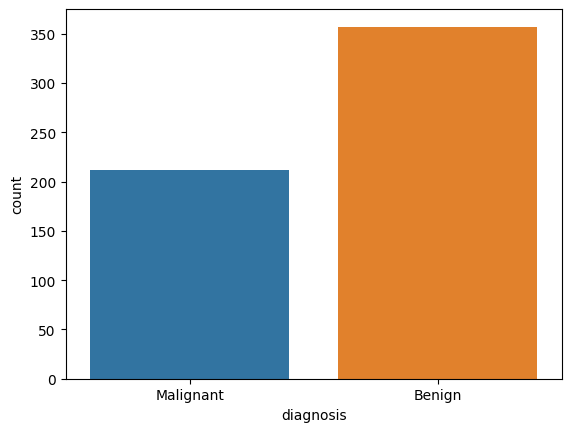

In [39]:
ax = sns.countplot(x = df['diagnosis'])
ax.set_xticklabels(['Malignant', 'Benign'])

## 4. Data manipulation

In [40]:
# drop useless column
df = df.drop(['Unnamed: 32', 'id'], axis = 1)
display(df)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [41]:
# Separate the target variable from the rest of the dataset
y = df['diagnosis']
features = df.drop(columns = ['diagnosis'])

In [42]:
# Transform the 'diagnosis' column into dummy/boolean columns
df = pd.get_dummies(df, columns = ['diagnosis'], drop_first = True)
boolean_columns = df.select_dtypes(include = 'bool')  # Select columns with boolean data type
df[boolean_columns.columns] = df[boolean_columns.columns].astype(int)  # Convert True/False to 0/1
df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


## 5. Malignancy prediction

### 5.1 - Data normalization

In [43]:
# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(features)
X = pd.DataFrame(X, columns = features.columns)

# Merge the data
df = X.copy()
df['diagnosis'] = y

### 5.2 - Train/ Split

In [44]:
X = df.drop("diagnosis", axis = 1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 666)

### 5.3 - Logistic regression

In [45]:
# Performing Logistic Regression
reg = LogisticRegression(max_iter = 10000)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_.flatten(), index = X_train.columns)

In [46]:
# Test the logistic regression
y_pred = reg.predict(X_test)

In [47]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index = ['Benign', 'Malignant'], columns = ['Predicted benignity', 'Predicted malignancy'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
           Predicted benignity  Predicted malignancy
Benign                     174                     0
Malignant                    7                   104


In [48]:
accuracy_score(y_test, y_pred)

0.9754385964912281

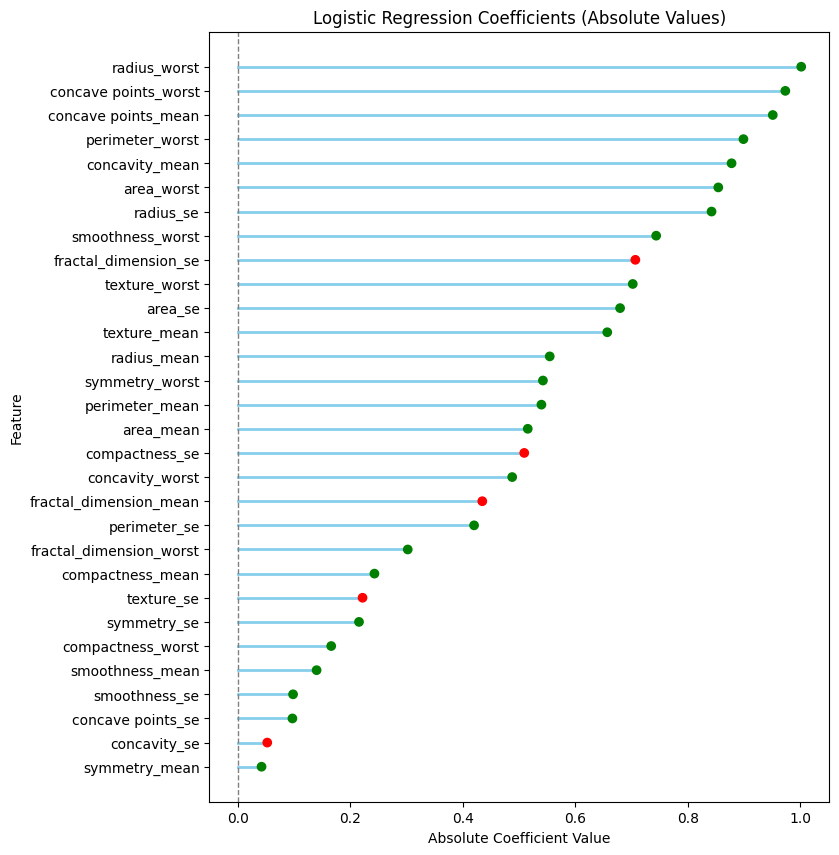

In [49]:
plot_sorted_coefficients(coef, regression_type = 'standard')

### 5.4 - Logistic Regression with L1 regularization

In [50]:
# Performing Logistic Regression with L1 regularization
reg = LogisticRegression(C = 0.05, solver = 'saga', penalty = 'l1', max_iter = 10000)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_.flatten(), index = X_train.columns)

In [51]:
# Test the logistic regression
y_pred = reg.predict(X_test)

In [52]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index = ['Benign', 'Malignant'], columns = ['Predicted benignity', 'Predicted malignancy'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
           Predicted benignity  Predicted malignancy
Benign                     174                     0
Malignant                   16                    95


In [53]:
accuracy_score(y_test, y_pred)

0.9438596491228071

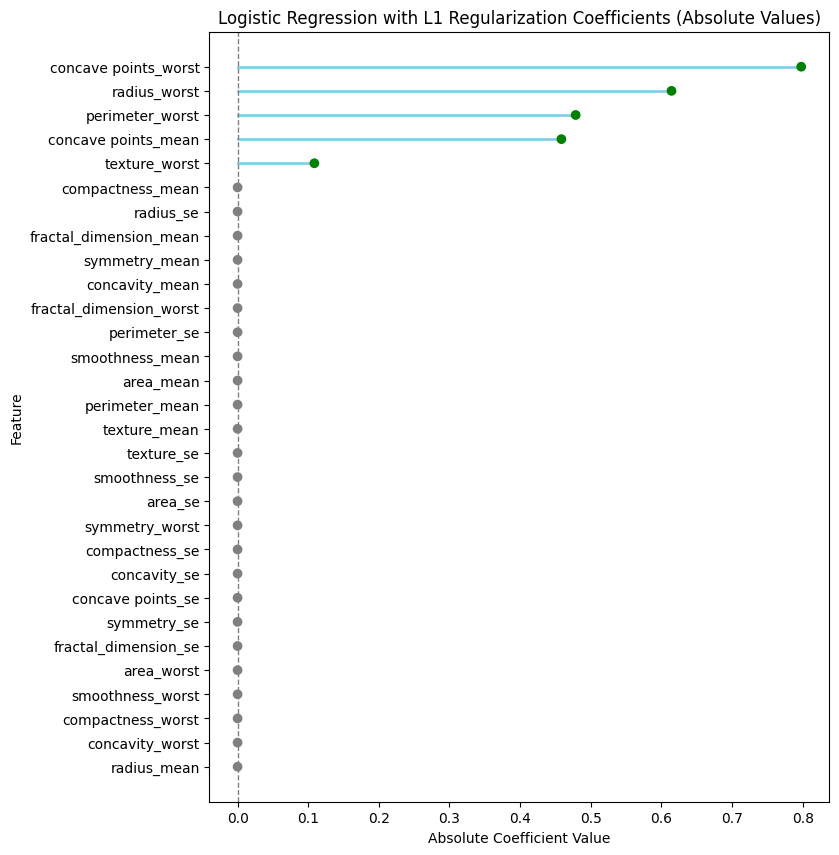

In [54]:
plot_sorted_coefficients(coef, regression_type = 'L1')

### 5.5 - Logistic regression with L2 regularization

In [55]:
# Performing Logistic Regression with L2 regularization
reg = LogisticRegression(penalty = 'l2', solver = 'saga', C = 0.01)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_[0], index=X.columns)

In [56]:
# Test the linear regression
y_pred = reg.predict(X_test)

In [57]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index = ['Benign', 'Malignant'], columns = ['Predicted benignity', 'Predicted malignancy'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
           Predicted benignity  Predicted malignancy
Benign                     174                     0
Malignant                   17                    94


In [58]:
accuracy_score(y_test, y_pred)

0.9403508771929825

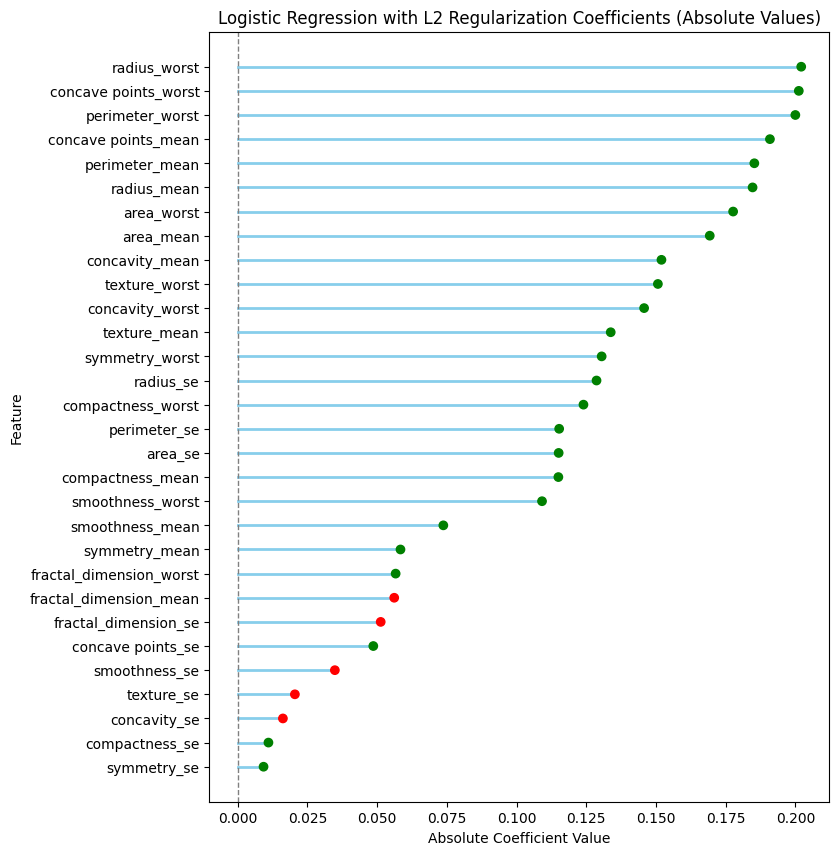

In [59]:
plot_sorted_coefficients(coef, regression_type = 'L2')

### 5.6 - Random forest

In [60]:
# Construct the random forest
model = RandomForestClassifier(n_estimators = 1000, random_state = 666, max_depth = 8)
model.fit(X_train, y_train)

y_pred_random_forest = model.predict(X_test)

In [61]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index = ['Benign', 'Malignant'], columns = ['Predicted benignity', 'Predicted malignancy'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
           Predicted benignity  Predicted malignancy
Benign                     174                     0
Malignant                   17                    94


In [62]:
accuracy_score(y_test, y_pred)

0.9403508771929825

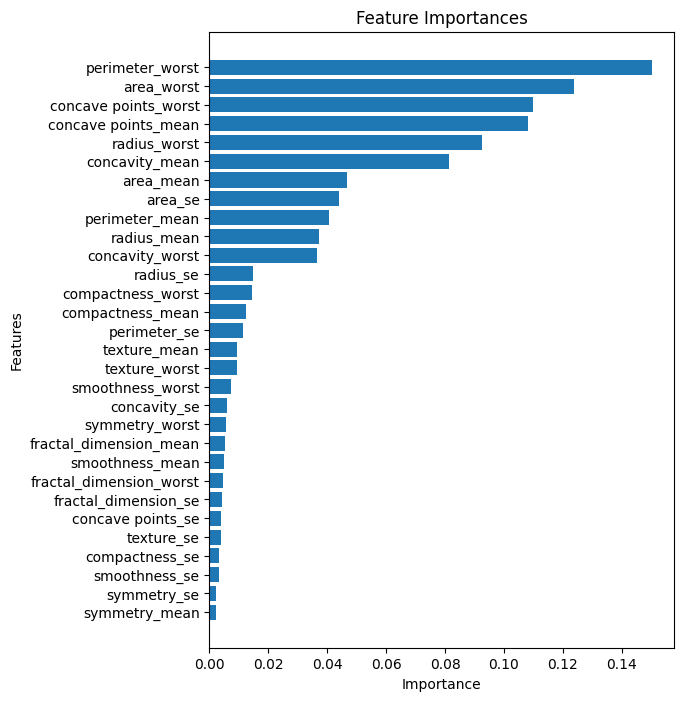

In [63]:
# Plot the feature importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6, 8))
plt.title("Feature Importances")
plt.barh(range(X_train.shape[1]), importances[indices], align = "center")
plt.yticks(ticks = range(X_train.shape[1]), labels = [X_train.columns[i] for i in indices])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # To have the most important feature at the top
plt.show()

### 5.7 - Neural classifier

In [64]:
# Large Neural Network with three hidden layers ([100,50] neurons)
clf_150_neurons = MLPClassifier(hidden_layer_sizes = (100,50), activation = 'relu',
                              solver = 'adam', max_iter = 1000, alpha = 10, tol = 1e-6, batch_size = 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_150_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons.predict(X_test)

c:\Users\elsab\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped


Iteration 1, loss = 2.69294892
Iteration 2, loss = 2.63078968
Iteration 3, loss = 2.57195739
Iteration 4, loss = 2.51642543
Iteration 5, loss = 2.46421362
Iteration 6, loss = 2.41494518
Iteration 7, loss = 2.36848461
Iteration 8, loss = 2.32467817
Iteration 9, loss = 2.28309703
Iteration 10, loss = 2.24368338
Iteration 11, loss = 2.20619791
Iteration 12, loss = 2.17041304
Iteration 13, loss = 2.13615853
Iteration 14, loss = 2.10327826
Iteration 15, loss = 2.07173539
Iteration 16, loss = 2.04135592
Iteration 17, loss = 2.01201649
Iteration 18, loss = 1.98361461
Iteration 19, loss = 1.95608777
Iteration 20, loss = 1.92935776
Iteration 21, loss = 1.90334618
Iteration 22, loss = 1.87800210
Iteration 23, loss = 1.85325992
Iteration 24, loss = 1.82906872
Iteration 25, loss = 1.80538948
Iteration 26, loss = 1.78216430
Iteration 27, loss = 1.75935116
Iteration 28, loss = 1.73693726
Iteration 29, loss = 1.71490503
Iteration 30, loss = 1.69321030
Iteration 31, loss = 1.67186239
Iteration 32, los

c:\Users\elsab\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.


In [65]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index = ['Benign', 'Malignant'], columns = ['Predicted benignity', 'Predicted malignancy'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
           Predicted benignity  Predicted malignancy
Benign                     174                     0
Malignant                    7                   104


In [66]:
accuracy_score(y_test, y_pred)

0.9754385964912281

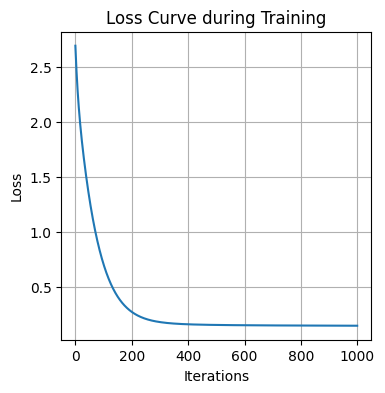

In [67]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## 6. Conclusion

The malignancy of a cancer can be predicted with an accuracy of 97.5% using a logistic regression or a neural network. This is better than relying on a logistic regression with L1 regularization or L2 regularization, with respective accuracies of 94.3% and 94.0%, or a Random Forest, which has an accuracy of 94.0%. With thoses maching learning methods, we can predict wether a cancer is malignant or begnin with a very good certainity knowing the characteristics of the cell nuclei. 

To take this a step further, it might be interesting to use data on the living habits of people who develop cancer, to know if those have consequences on the malignancy of a cancer.

## 7. Bonus - diagnosis

In [68]:
# diagnosis 
y_train_pred = clf_150_neurons.predict(X_train)
accuracy_score(y_train, y_train_pred)

0.9929577464788732

From these results, we can conclude that the neural network minimises bias and maximises variance. It therefore provides the best possible prediction of whether a cancer is malignant or benign, based on the characteristics of the cell.